In [1]:
!pip install --upgrade scikit-learn scikit-learn==1.7.2 xgboost==3.1.3 lightgbm==4.6.0 catboost==1.2.8
!pip install -qq pytabkit
from pytabkit import RealMLP_TD_Classifier, TabM_D_Classifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 76.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.0/364.0 kB 13.9 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder, label_binarize, OrdinalEncoder, QuantileTransformer, TargetEncoder, RobustScaler
from category_encoders import CatBoostEncoder, MEstimateEncoder

from sklearn.ensemble import RandomForestClassifier, VotingClassifier, HistGradientBoostingClassifier, GradientBoostingClassifier, HistGradientBoostingRegressor, AdaBoostRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import RidgeClassifier, LogisticRegression, LinearRegression, BayesianRidge, Ridge, ElasticNet, Lasso
from sklearn import set_config
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import optuna
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve, root_mean_squared_error, mean_squared_error, precision_recall_curve, make_scorer, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, matthews_corrcoef, r2_score
from scipy.stats import norm, skew
from scipy.special import expit, logit 

from colorama import Fore, Style, init
from copy import deepcopy
from sklearn.base import BaseEstimator, TransformerMixin
from pprint import pprint
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, StratifiedKFold, KFold, RepeatedKFold, cross_val_score, StratifiedGroupKFold
from sklearn.isotonic import IsotonicRegression
from xgboost import DMatrix, XGBClassifier, XGBRegressor
import xgboost as xgb
from lightgbm import log_evaluation, early_stopping, LGBMClassifier, LGBMRegressor, Dataset
import lightgbm
from catboost import CatBoostClassifier, CatBoostRegressor, Pool
from tqdm.notebook import tqdm
from optuna.samplers import TPESampler, CmaEsSampler
from optuna.pruners import HyperbandPruner
from functools import partial
from IPython.display import display_html, clear_output
from sklearn.utils.class_weight import compute_class_weight
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
import gc
import re
from typing import Literal, NamedTuple
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap
from sklearn.inspection import permutation_importance

import keras
from keras.models import Sequential
from keras import layers
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

import math
import random
from copy import deepcopy
from typing import Any, Literal, NamedTuple, Optional
import torch

E0000 00:00:1773076485.598031      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773076485.681782      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773076486.389139      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773076486.389211      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773076486.389215      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773076486.389218      17 computation_placer.cc:177] computation placer already registered. Please check linka

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">Configuration</p>

In [3]:
class Config:
    target = 'Churn'
    train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv', index_col='id')
    test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv', index_col='id')
    submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv')
    orig = pd.read_csv('/kaggle/input/datasets/cdeotte/s6e3-original-dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv')[train.columns]
    
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    state = 42
    n_splits = 10
    early_stop = 100
    metric = 'roc_auc'
    task_type = "binary"
    task_is_regression = task_type == 'regression'
    if task_is_regression:
        n_classes = None
    else:
        n_classes = train[target].nunique()
        labels = list(train[target].unique())

    orig['TotalCharges'] = pd.to_numeric(orig['TotalCharges'], errors='coerce')
    orig['TotalCharges'].fillna(orig['TotalCharges'].median(), inplace=True)
    train[target] = (train[target] == 'Yes').astype(int)
    orig[target] = (orig[target] == 'Yes').astype(int)
    
    folds = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=state)

    outliers = False
    log_trf = False
    missing = False

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">EDA</p>

In [4]:
class EDA(Config):
    
    def __init__(self):
        super().__init__()

        self.cat_features = self.train.drop(self.target, axis=1).select_dtypes(include=['object', 'bool']).columns.tolist()
        self.num_features = self.train.drop(self.target, axis=1).select_dtypes(exclude=['object', 'bool']).columns.tolist()
        self.data_info()
        self.heatmap()
        self.dist_plots()
        self.cat_feature_plots()
        if self.task_is_regression:
            self.target_plot()
        else:
            self.target_pie()
                
    def data_info(self):
        
        for data, label in zip([self.train, self.test], ['Train', 'Test']):
            table_style = [{'selector': 'th:not(.index_name)',
                            'props': [('background-color', '#3cb371'),
                                      ('color', '#FFFFFF'),
                                      ('font-weight', 'bold'),
                                      ('border', '1px solid #DCDCDC'),
                                      ('text-align', 'center')]
                            }, 
                            {'selector': 'tbody td',
                             'props': [('border', '1px solid #DCDCDC'),
                                       ('font-weight', 'normal')]
                            }]
            print(Style.BRIGHT+Fore.GREEN+f'\n{label} head\n')
            display(data.head().style.set_table_styles(table_style))
                           
            print(Style.BRIGHT+Fore.GREEN+f'\n{label} info\n'+Style.RESET_ALL)               
            display(data.info())
                           
            print(Style.BRIGHT+Fore.GREEN+f'\n{label} describe\n')
            display(data.describe().drop(index='count', columns=self.target, errors = 'ignore').T
                    .style.set_table_styles(table_style).format('{:.3f}'))
            
            print(Style.BRIGHT+Fore.GREEN+f'\n{label} missing values\n'+Style.RESET_ALL)               
            display(data.isna().sum())
        return self
    
    def heatmap(self):
        print(Style.BRIGHT+Fore.GREEN+f'\nCorrelation Heatmap\n')
        plt.figure(figsize=(10, 10))
        corr = self.train[self.num_features+[self.target]].corr(method='pearson')
        sns.heatmap(corr, fmt = '0.2f', cmap = 'Greens', square=True, annot=True, linewidths=1, cbar=False)
        plt.show()
        
    def dist_plots(self):
        print(Style.BRIGHT+Fore.GREEN+f"\nDistribution analysis\n")
        df = pd.concat([self.train[self.num_features].assign(Source = 'Train'), 
                        self.test[self.num_features].assign(Source = 'Test'),], 
                        axis=0, ignore_index = True)

        fig, axes = plt.subplots(len(self.num_features), 2 ,figsize = (18, len(self.num_features) * 6), 
                                 gridspec_kw = {'hspace': 0.3, 
                                                'wspace': 0.2, 
                                                'width_ratios': [0.70, 0.30]
                                               }
                                )
        for i,col in enumerate(self.num_features):
            ax = axes[i,0]
            sns.kdeplot(data = df[[col, 'Source']], x = col, hue = 'Source', 
                        palette = ['#3cb371', '#ef5350'], ax = ax, linewidth = 2
                       )
            ax.set(xlabel = '', ylabel = '')
            ax.set_title(f"\n{col}")
            ax.grid()

            ax = axes[i,1]
            sns.boxplot(data = df, y = col, x=df.Source, width = 0.5,
                        linewidth = 1, fliersize= 1,
                        ax = ax, palette=['#3cb371', '#ef5350']
                       )
            ax.set_title(f"\n{col}")
            ax.set(xlabel = '', ylabel = '')
            ax.tick_params(axis='both', which='major')
            ax.set_xticklabels(['Train', 'Test'])

        plt.tight_layout()
        plt.show()
               
    def cat_feature_plots(self):
        fig, axes = plt.subplots(max(len(self.cat_features), 1), 2 ,figsize = (18, len(self.cat_features) * 6), 
                                 gridspec_kw = {'hspace': 0.5, 
                                                'wspace': 0.2,
                                               }
                                )
        if len(self.cat_features) == 1:
            axes = np.array([axes])
            
        for i, col in enumerate(self.cat_features):
            ax = axes[i,0]
            sns.barplot(data=self.train[col].value_counts().nlargest(10).reset_index(), x=col, y='count', ax=ax, color='#3cb371')
            ax.set(xlabel = '', ylabel = '')
            ax.set_title(f"\n{col} Train")
            
            ax = axes[i,1]
            sns.barplot(data=self.train[col].value_counts().nlargest(10).reset_index(), x=col, y='count', ax=ax, color='#ef5350')
            ax.set(xlabel = '', ylabel = '')
            ax.set_title(f"\n{col} Test")

        plt.tight_layout()
        plt.show()

    def target_pie(self):
        print(Style.BRIGHT+Fore.GREEN+f"\nTarget feature distribution\n")
        plt.figure(figsize=(6, 6))
        plt.pie(self.train[self.target].value_counts(), labels=self.labels, autopct='%1.2f%%', colors=['#ef5350', '#3cb371'])
        plt.show()

    def target_plot(self):
        print(Style.BRIGHT+Fore.GREEN+f"\nTarget feature distribution\n")
        
        fig, axes = plt.subplots(1, 2 ,figsize = (14, 6), 
                                 gridspec_kw = {'hspace': 0.3, 
                                                'wspace': 0.2, 
                                                'width_ratios': [0.70, 0.30]
                                               }
                                )
        ax = axes[0]
        sns.kdeplot(data = self.train[self.target], 
                    color = '#3cb371', ax = ax, linewidth = 2
                   )
        ax.set(xlabel = '', ylabel = '')
        ax.set_title(f"\n{self.target}")
        ax.grid()

        ax = axes[1]
        sns.boxplot(data = self.train, y = self.target, width = 0.5,
                    linewidth = 1, fliersize= 1,
                    ax = ax, color = '#3cb371'
                   )
        ax.set_title(f"\n{self.target}")
        ax.set(xlabel = '', ylabel = '')
        ax.tick_params(axis='both', which='major')

        plt.tight_layout()
        plt.show() 


Train head



,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,,,,,,,,,,,,,,,,,,,,
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.100000,1653.850000,0
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.500000,3778.200000,0
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.400000,5841.350000,0
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.700000,70.700000,1
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.450000,70.450000,1



Train info

<class 'pandas.core.frame.DataFrame'>
Index: 594194 entries, 0 to 594193
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   gender            594194 non-null  object 
 1   SeniorCitizen     594194 non-null  int64  
 2   Partner           594194 non-null  object 
 3   Dependents        594194 non-null  object 
 4   tenure            594194 non-null  int64  
 5   PhoneService      594194 non-null  object 
 6   MultipleLines     594194 non-null  object 
 7   InternetService   594194 non-null  object 
 8   OnlineSecurity    594194 non-null  object 
 9   OnlineBackup      594194 non-null  object 
 10  DeviceProtection  594194 non-null  object 
 11  TechSupport       594194 non-null  object 
 12  StreamingTV       594194 non-null  object 
 13  StreamingMovies   594194 non-null  object 
 14  Contract          594194 non-null  object 
 15  PaperlessBilling  594194 non-null  object 
 16  PaymentMetho

None


Train describe



...


Test describe



,mean,std,min,25%,50%,75%,max
SeniorCitizen,0.114,0.317,0.000,0.000,0.000,0.000,1.000
tenure,37.280,24.778,1.000,13.000,36.000,62.000,72.000
MonthlyCharges,66.131,31.104,18.300,30.150,74.350,91.100,118.750
TotalCharges,2544.617,2348.124,18.800,677.625,1468.750,4317.300,8684.800



Test missing values



gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


Correlation Heatmap



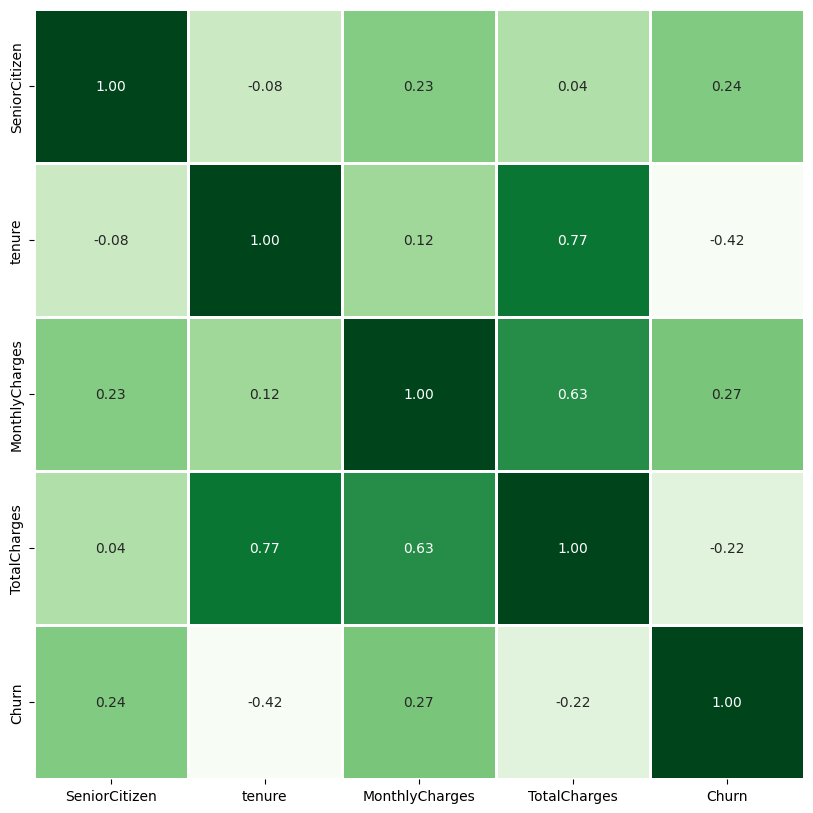


Distribution analysis



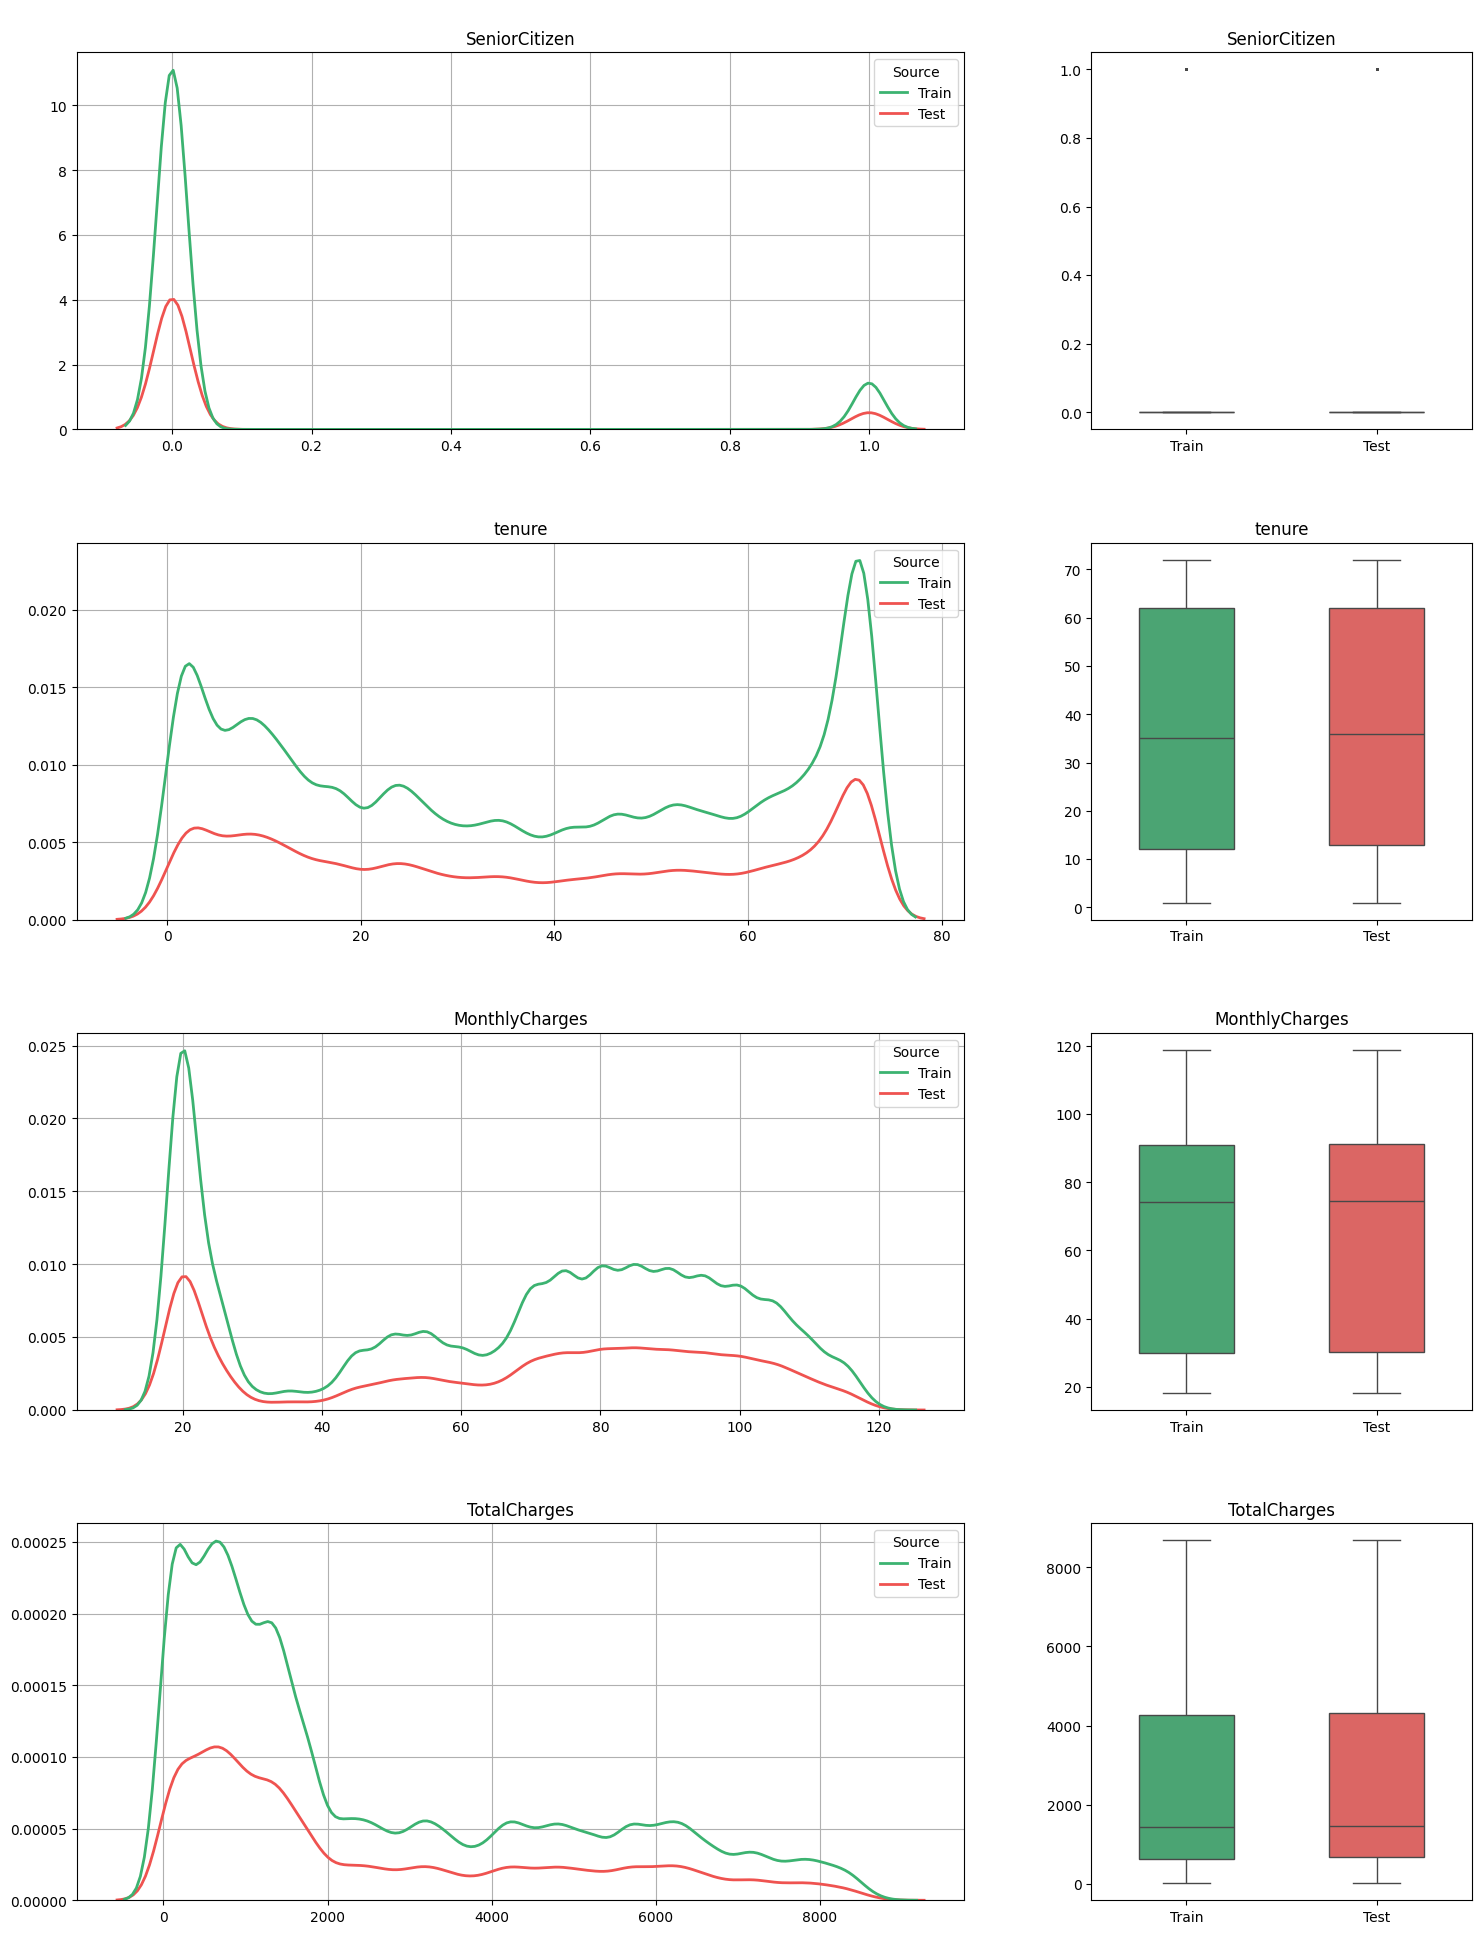

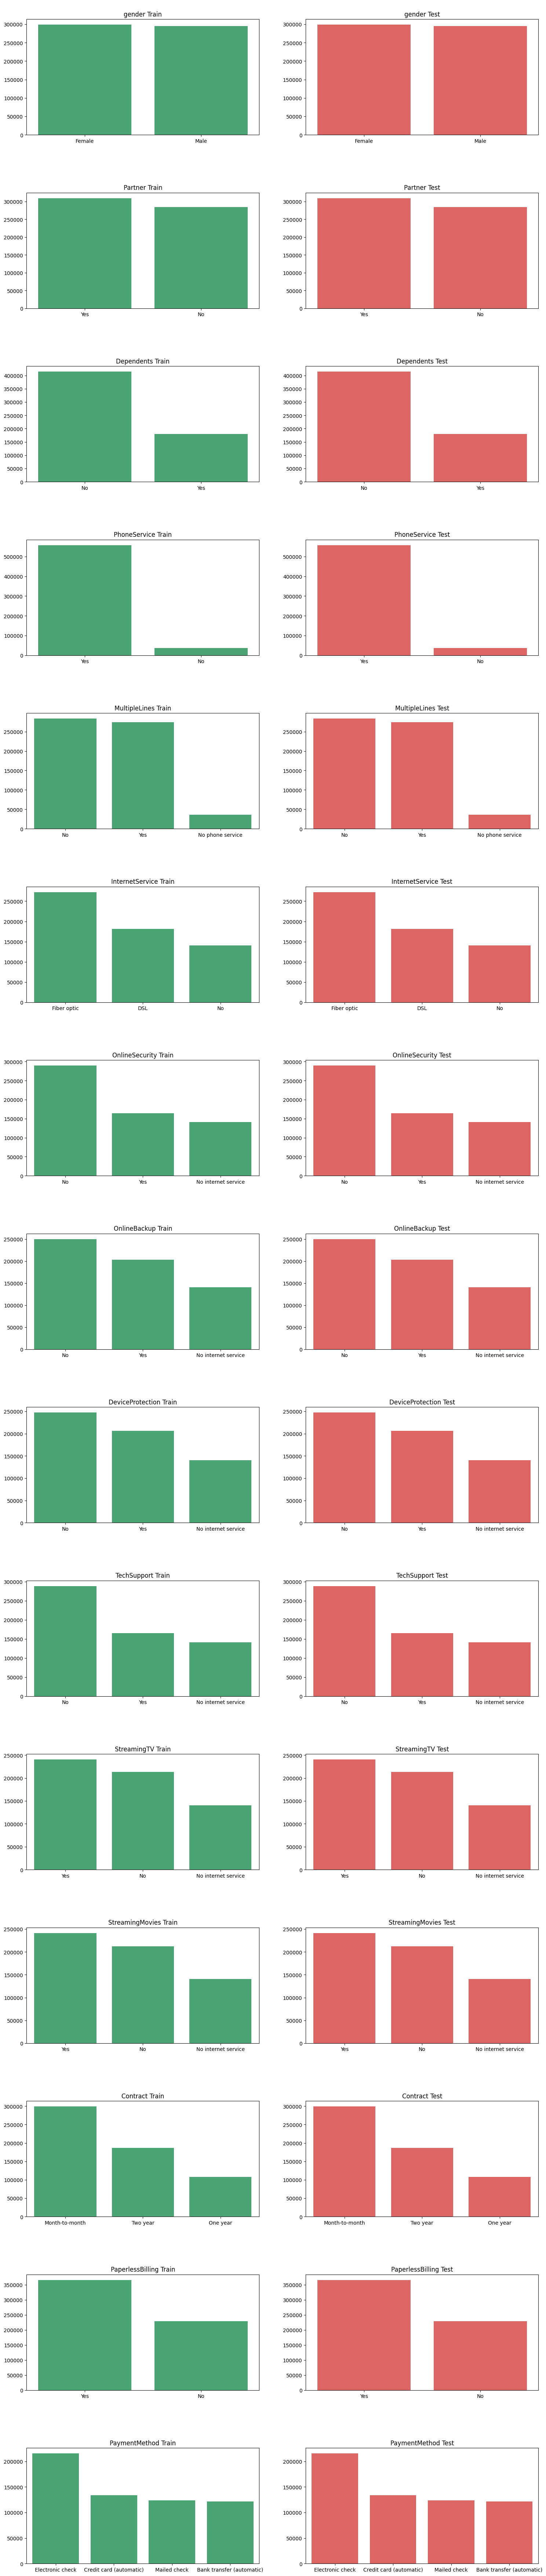


Target feature distribution



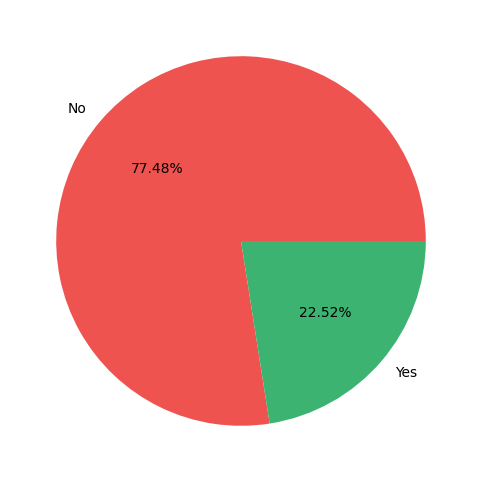

In [5]:
eda = EDA()

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">Preprocessing</p>

In [6]:
class Preprocessing(Config):
    
    def __init__(self):
        super().__init__()

    def fit_transform(self):
        self.prepare_data()
        if self.missing:
            self.missing_values()

        global_stats = {'mean': self.orig[self.target].mean(), 'count': 0}
        stats = {}
        for c in self.num_features + self.cat_features:
            stats[c] = self.orig.groupby(c)[self.target].agg(['mean'])
        
        self.X = self.add_target_stats(self.X, stats, global_stats)
        self.test = self.add_target_stats(self.test, stats, global_stats)
        
        combine = pd.concat([self.X, self.test])
        combine = self.feature_engineering(combine)
        self.X = combine.iloc[:len(self.X)].copy()
        self.test = combine.iloc[len(self.X):].copy()
        
        all_cats = self.numtocat_features+self.cat_features+self.bin_features+self.num_features
        self.fit_frequency_encoding(self.X, all_cats)
        self.X = self.apply_frequency_encoding(self.X, all_cats)
        self.test = self.apply_frequency_encoding(self.test, all_cats)

        self.num_features = self.test.select_dtypes(exclude=['object', 'bool', 'category']).columns.tolist()
        self.cat_features = self.test.select_dtypes(include=['object', 'bool','category']).columns.tolist()

        if self.outliers:
            self.remove_outliers()
        if self.log_trf:
            self.log_transformation()

        return self.X, self.y, self.test, self.cat_features, self.num_features

    def prepare_data(self):
        self.train_raw = self.train.copy()
        self.y = self.train[self.target]
        self.X = self.train.drop(self.target, axis=1)
    
        self.num_features = self.X.select_dtypes(exclude=['object', 'bool']).columns.tolist()
        self.cat_features = self.X.select_dtypes(include=['object', 'bool']).columns.tolist()
        
    def add_target_stats(self, df, stats, global_stats):
        df = df.copy()
        for c, agg in stats.items():
            for a in ['mean']:
                col = f"{c}_org_{a}"
                tmp = agg[a].rename(col).reset_index()
                df = df.merge(tmp, on=c, how='left')
                df[col] = df[col].fillna(global_stats[a])
        return df
    
    def fit_frequency_encoding(self, X, features):
        self.freq_encodings = {}
        for c in features:
            freqs = X[c].value_counts(normalize=True).to_dict()
            self.freq_encodings[c] = freqs

    def apply_frequency_encoding(self, X, features):
        X = X.copy()
        for c in features:
            mapping = self.freq_encodings.get(c, {})
            X[f"{c}_fe"] = X[c].map(mapping).astype(float).fillna(0)
        return X

    def feature_engineering(self, df):
        highcard = [c for c in self.num_features if df[c].nunique() > 20]
        lowcard = [col for col in self.num_features if col not in highcard]
        
        self.bin_features = []
        for c in highcard: 
            df[f"{c}_bin"] = pd.qcut(df[c], q=5, labels=False, duplicates='drop')
            df[f"{c}_bin"] = df[f"{c}_bin"].astype("category") 
            self.bin_features.append(f"{c}_bin")  
        
        self.numtocat_features = []
        for c in self.num_features: 
            df[f"{c}_cat"] = df[c].astype('category')
            self.numtocat_features.append(f"{c}_cat")

        df['charges_deviation']      = (df['TotalCharges'] - df['tenure'] * df['MonthlyCharges']).astype('float32')
        df['monthly_to_total_ratio'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1)).astype('float32')
        df['avg_monthly_charges']    = (df['TotalCharges'] / (df['tenure'] + 1)).astype('float32')

        SERVICE_COLS = [
            "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
            "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
        ]
        df["service_count"] = (df[SERVICE_COLS] == "Yes").sum(axis=1).astype("float32")
        df["tenure_x_monthly"] = (df["tenure"] * df["MonthlyCharges"]).astype("float32")
        df["tenure_x_service"] = (df["tenure"] * df["service_count"]).astype("float32")
        
        df[self.cat_features] = df[self.cat_features].astype('category')

        return df
        
    def log_transformation(self):
        self.y = np.log1p(self.y)

    def remove_outliers(self):
        Q1 = self.y.quantile(0.25)
        Q3 = self.y.quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        mask = (self.y >= lower_limit) & (self.y <= upper_limit)
        self.X = self.X[mask]
        self.y = self.y[mask]
        self.X.reset_index(drop=True, inplace=True)

    def missing_values(self):
        self.X[self.cat_features] = self.X[self.cat_features].fillna('NaN')
        self.test[self.cat_features] = self.test[self.cat_features].fillna('NaN')

In [7]:
X, y, test, cat_features, num_features = Preprocessing().fit_transform()

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">Models</p>

In [8]:
import contextlib, io
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator
import ydf


class YDFModel(BaseEstimator, Config):
    def __init__(self, params=None):
        self.params = {} if params is None else params.copy()
        self.learner_class = ydf.GradientBoostedTreesLearner

    def fit(self, X: pd.DataFrame, y: pd.Series,
           X_val: pd.DataFrame=None, y_val: pd.Series=None):
        assert isinstance(X, pd.DataFrame)
        assert isinstance(y, pd.Series)

        if not self.task_is_regression:
            y = y.astype(int)
            y_val = y_val.astype(int)

        target = y.name
        params = self.params.copy()
        params["label"] = target
        params["task"] = (
            ydf.Task.REGRESSION if self.task_is_regression
            else ydf.Task.CLASSIFICATION
        )

        df = X.copy()
        df[target] = y.values
        valid_dataset = None
        if X_val is not None and y_val is not None:
            valid_dataset = X_val.copy()
            valid_dataset[target] = y_val.values
            
        supports_valid = self.learner_class is ydf.GradientBoostedTreesLearner
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            if supports_valid and valid_dataset is not None:
                self.model = self.learner_class(**params).train(df, valid=valid_dataset)
            else:
                self.model = self.learner_class(**params).train(df)


        if not self.task_is_regression:
            self.classes_ = np.sort(y.unique())
            self.n_classes_ = len(self.classes_)

        return self

    def predict(self, X: pd.DataFrame):
        assert isinstance(X, pd.DataFrame)
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            raw_pred = self.model.predict(X)

        if self.task_is_regression:
            return np.asarray(raw_pred)
        else:
            proba = np.asarray(raw_pred)

            if proba.ndim == 1:
                proba = np.vstack([1 - proba, proba]).T
            idx = proba.argmax(axis=1)
            return self.classes_[idx]

    def predict_proba(self, X: pd.DataFrame):
        if self.task_is_regression:
            raise AttributeError("predict_proba is not available for regression task")
        assert isinstance(X, pd.DataFrame)
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            raw_pred = self.model.predict(X)

        proba = np.asarray(raw_pred)
        if proba.ndim == 1:
            proba = np.vstack([1 - proba, proba]).T

        order = np.argsort(self.classes_)
        return proba[:, order]

In [9]:
models = {
    'XGB2': XGBClassifier(**{'n_estimators': 50000,
                             'learning_rate': 0.05,
                             'max_depth': 6,
                             'subsample': 0.8,
                             'colsample_bytree': 0.8,
                             'min_child_weight': 5,
                             'reg_alpha': 0.1,
                             'reg_lambda': 1.0,
                             'gamma': 0.05,
                             'random_state': Config.state,
                             'early_stopping_rounds': 500,
                             'objective': 'binary:logistic',
                             'eval_metric': 'auc',
                             'enable_categorical': True,
                             'device': 'cuda',
                             'verbosity': 0,
                            }),
    'XGB3': XGBClassifier(**{'tree_method': 'hist',
                             'objective': 'binary:logistic',
                             'random_state': Config.state,
                             'enable_categorical': True,
                             'verbosity': 0,
                             'eval_metric': 'auc',
                             'booster': 'gbtree',
                             'n_jobs': -1,
                             'learning_rate': 0.01,
                             'n_estimators': 20000,
                             "device": "cuda",                             
                             'early_stopping_rounds': Config.early_stop,
                             'lambda': 4.0423741997416265,
                             'alpha': 1.0838672945853611,
                             'colsample_bytree': 0.26890721980442933,
                             'subsample': 0.8829137576892285,
                             'max_depth': 4, 
                             'min_child_weight': 3
                             }),
    'Realmlp': RealMLP_TD_Classifier(**{'val_metric_name': '1-auc_ovo',
                                        'device': 'cuda',
                                        'random_state': 42,
                                        'verbosity': 2,
                                        'n_epochs': 100,
                                        'batch_size': 256, 
                                        'n_ens': 8, 
                                        'use_early_stopping': True,
                                        'early_stopping_additive_patience': 10,
                                        'early_stopping_multiplicative_patience': 1,
                                        'act': "mish",
                                        'embedding_size': 8,
                                        'first_layer_lr_factor': 0.5962121993798933,
                                        'hidden_sizes': "rectangular",
                                        'hidden_width': 384,
                                        'lr': 0.04, 
                                        'ls_eps': 0.011498317194338772,
                                        'ls_eps_sched': "coslog4",
                                        'max_one_hot_cat_size': 18,
                                        'n_hidden_layers': 4, 
                                        'p_drop': 0.07301419697186451,
                                        'p_drop_sched': "flat_cos",
                                        'plr_hidden_1': 16, 
                                        'plr_hidden_2': 8,
                                        'plr_lr_factor': 0.1151437622270563,
                                        'plr_sigma': 2.3316811282666916,
                                        'scale_lr_factor': 2.244801835541429,
                                        'sq_mom': 1.0 - 0.011834054955582318,
                                        'wd': 0.02369230879235962,
                                        }),
    'LGBM': LGBMClassifier(**{'random_state': Config.state,
                              'early_stopping_round': Config.early_stop,
                              'verbose': -1,
                              'n_estimators': 20000,
                              'metric': 'AUC',
                              'objective': 'binary',
                              'learning_rate': 0.01,
                              'max_depth': 4, 
                              'min_child_samples': 157,
                              'subsample': 0.6257655427368182,
                              'colsample_bytree': 0.530521018997706, 
                              'num_leaves': 276, 
                              'reg_alpha': 1.6538434614541166, 
                              'reg_lambda': 0.04482898059306972
                             }),
    'LGBM2': LGBMClassifier(**{'random_state': Config.state,
                               'early_stopping_round': Config.early_stop,
                               'verbose': -1,
                               'n_estimators': 20000,
                               'metric': 'AUC',
                               'objective': 'binary',
                               'learning_rate': 0.01,
                               'max_depth': 8,
                               'min_child_samples': 235,
                               'subsample': 0.337666141806675,
                               'colsample_bytree': 0.2226210141914259,
                               'num_leaves': 489,
                               'reg_alpha': 3.8253448900202276,
                               'reg_lambda': 0.020738826483719237
                               }),
    'LR_2': LogisticRegression(penalty="l2", 
                             solver="lbfgs", 
                             C = 1.0, 
                             random_state = Config.state, 
                             max_iter = 1000
                            ),
    'CAT_3': CatBoostClassifier(**{'verbose': 0,
                                 'loss_function':'Logloss',
                                 'random_state': Config.state,
                                 'cat_features': cat_features,
                                 'early_stopping_rounds': Config.early_stop,
                                 'eval_metric': "AUC",
                                 'n_estimators' : 20000,
                                 'learning_rate': 0.01,
                                 "task_type": "GPU",
                                 'depth': 4,
                                 'min_data_in_leaf': 42, 
                                 'l2_leaf_reg': 0.010507739182123475,
                                 'bagging_temperature': 0.3075597140802794,
                                 'random_strength': 9.908572822935072
                                 }),
    'CAT2': CatBoostClassifier(**{'verbose': 0,
                                  'loss_function':'Logloss',
                                  'random_state': Config.state,
                                  'cat_features': cat_features,
                                  'early_stopping_rounds': Config.early_stop,
                                  'eval_metric': "AUC",
                                  'n_estimators' : 20000,
                                  'learning_rate': 0.01,
                                  "task_type": "GPU",
                                  'depth': 6,
                                  'min_data_in_leaf': 82, 
                                  'l2_leaf_reg': 1.3709268695435266,
                                  'bagging_temperature': 0.3012708382193271, 
                                  'random_strength': 1.9005762297933753
                                  }),
    'HGB': HistGradientBoostingClassifier(**{'max_iter': 20000,
                                             'random_state': Config.state,
                                             'early_stopping': True,
                                             'categorical_features': "from_dtype",
                                             'learning_rate': 0.01,
                                             'loss': 'log_loss',
                                             'scoring': 'loss',
                                             'l2_regularization': 1.7212335224684774e-09, 
                                             'max_depth': 6, 
                                             'max_leaf_nodes': 110, 
                                             'min_samples_leaf': 45
                                             }),
    'TabMD':TabM_D_Classifier(**{'batch_size': 'auto',
                                 'patience': 16,
                                 'allow_amp': True,
                                 'arch_type': 'tabm-mini',
                                 'tabm_k': 8,
                                 'gradient_clipping_norm': 1.0, 
                                 'share_training_batches': False,
                                 'lr': 1e-3,
                                 'weight_decay': 1e-3,
                                 'n_blocks': 3,
                                 'd_block': 512, 
                                 'dropout': 0.0, 
                                 'num_emb_type': 'pwl',
                                 'd_embedding': 32,
                                 'num_emb_n_bins': 119,
                                }),
}

In [10]:
class FeatureEncoder:
    def __init__(self, num_features, cat_features):
        self.num_features = num_features
        self.cat_features = cat_features
        self.ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        self.scaler = StandardScaler()
        self.ohe_cols = None

    def fit(self, X):
        self.ohe.fit(X[self.cat_features])
        self.ohe_cols = self.ohe.get_feature_names_out(self.cat_features)
        self.scaler.fit(X[self.num_features])
        
    def transform_fold(self, X_train, X_val, X_test):
        def transform(X):
            X[self.num_features] = self.scaler.transform(X[self.num_features])

            X_ohe = self.ohe.transform(X[self.cat_features])
            X_ohe_df = pd.DataFrame(X_ohe, columns=self.ohe_cols, index=X.index)   
            X = pd.concat([X.drop(columns=self.cat_features).reset_index(drop=True),
                                        X_ohe_df.reset_index(drop=True)], axis=1)
            return X
        return transform(X_train), transform(X_val), transform(X_test)

In [11]:
class Trainer(Config):
    
    def __init__(self, X, y, test, models, num_features, cat_features, training=True):
        self.X = X
        self.test = test
        self.y = y
        self.models = models
        self.training = training
        self.scores = pd.DataFrame(columns=['Score'], dtype=float)
        self.OOF_preds = pd.DataFrame(dtype=float)
        self.TEST_preds = pd.DataFrame(dtype=float)
        self.num_features = num_features
        self.cat_features = cat_features

    def ScoreMetric(self, y_true, y_pred):
        if self.metric == 'roc_auc':
            return roc_auc_score(y_true, y_pred, multi_class="ovr") if self.n_classes > 2 else roc_auc_score(y_true, y_pred)
        elif self.metric == 'accuracy':
            return accuracy_score(y_true, y_pred)
        elif self.metric == 'f1':
            return f1_score(y_true, y_pred, average='weighted') if self.n_classes > 2 else f1_score(y_true, y_pred)
        elif self.metric == 'precision':
            return precision_score(y_true, y_pred, average='weighted') if self.n_classes > 2 else precision_score(y_true, y_pred)
        elif self.metric == 'recall':
            return recall_score(y_true, y_pred, average='weighted') if self.n_classes > 2 else recall_score(y_true, y_pred)
        elif self.metric == 'mae':
            return mean_absolute_error(y_true, y_pred)
        elif self.metric == 'r2':
            return r2_score(y_true, y_pred)
        elif self.metric == 'rmse':
            return root_mean_squared_error(y_true, y_pred)
        elif self.metric == 'rmsle':
            return root_mean_squared_error(y_true, y_pred)
        elif self.metric == 'mse':
            return mean_squared_error(y_true, y_pred, squared=True)

    def train(self, model, X, y, test, model_name):
        oof_pred = np.zeros(X.shape[0], dtype=float)
        test_pred = np.zeros(test.shape[0], dtype=float)

        print('='*20)
        print(model_name)
        params=model.get_params()
        for n_fold, (train_id, valid_id) in enumerate(self.folds.split(X, y)):
            features = X.columns.to_list()

            X_train = X[features].loc[train_id].copy()
            y_train = y[train_id]
            X_val = X[features].iloc[valid_id].copy()
            y_val = y[valid_id]
            X_test = test[features].copy()

            if model_name != 'Ensemble':
                te = TargetEncoder(random_state=42, shuffle=True, cv=10, smooth='auto', target_type='binary')         
                X_train[self.cat_features] = te.fit_transform(X_train[self.cat_features], y_train).astype('float32')
                X_val[self.cat_features] = te.transform(X_val[self.cat_features]).astype('float32')
                X_test[self.cat_features] = te.transform(X_test[self.cat_features]).astype('float32')
                
            num_features = X_train.select_dtypes(exclude=['category']).columns.tolist()
            cat_features = X_train.select_dtypes(include=['category']).columns.tolist()
            print(f'Fold {n_fold+1}')
            
            if "LGBM" in model_name:
                model.fit(
                    X_train, y_train,
                    eval_set=[(X_val, y_val)],
                    categorical_feature=cat_features,
                    feature_name="auto",
                    callbacks=[log_evaluation(0), early_stopping(self.early_stop, verbose=False)]
                )

            elif any(model in model_name for model in ["FTT", "TabMD", 'ResNet', 'Realmlp']):
                model.fit(
                    X_train, y_train,
                    X_val, y_val,
                    cat_col_names=cat_features
                )
            
            elif any(model in model_name for model in ["NN", "TabM"]):
                model.num_features = X_train.select_dtypes(exclude=['category']).columns.tolist()
                model.cat_features = X_train.select_dtypes(include=['category']).columns.tolist()
                model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

            elif any(model in model_name for model in ['CAT', 'XGB']):
                model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
                
            elif any(model in model_name for model in ["HGB", "YDF"]):
                model.fit(X_train, y_train, X_val=X_val, y_val=y_val)
                
            elif "Ensemble" in model_name:
                model = Pipeline([
                    ("scaler", StandardScaler(with_mean=True, with_std=True)),
                    ("ridge", model)
                ])
                model.fit(X_train, y_train)
                
            else:
                encoder = FeatureEncoder(num_features=num_features, cat_features=cat_features)
                encoder.fit(X_train)
                X_train, X_val, X_test = encoder.transform_fold(X_train, X_val, X_test)          
                model.fit(X_train, y_train)

            if self.task_type == "regression" :
                y_pred_val = model.predict(X_val)           
                test_pred += model.predict(X_test) / self.n_splits
            elif self.task_type == "binary" :
                y_pred_val = model.predict_proba(X_val)[:, 1]            
                test_pred += model.predict_proba(X_test)[:, 1] / self.n_splits
            elif self.task_type == "multiclass" :
                y_pred_val = model.predict_proba(X_val)            
                test_pred += model.predict_proba(X_test) / self.n_splits
                
            oof_pred[valid_id] = y_pred_val
            score = self.ScoreMetric(y_val, y_pred_val)
            print(score)
            self.scores.loc[f'{model_name}', f'Fold {n_fold+1}'] = score

        self.scores.loc[f'{model_name}', 'Score'] = self.scores.loc[f'{model_name}'][1:].mean()

        return oof_pred, test_pred

    def run(self):
        for model_name, model in tqdm(self.models.items()):

            if self.training:                
                X = self.X.copy()
                test = self.test.copy()

                oof_pred, test_pred = self.train(model, X, self.y, test, model_name)
                pd.DataFrame(oof_pred, columns=[f'{model_name}']).to_csv(f'{model_name}_oof.csv', index=False)
                pd.DataFrame(test_pred, columns=[f'{model_name}']).to_csv(f'{model_name}_test.csv', index=False)
            
            else:
                oof_pred = pd.read_csv(f'/kaggle/input/datasets/mikhailnaumov/churn-models/{model_name}_oof.csv')
                test_pred = pd.read_csv(f'/kaggle/input/datasets/mikhailnaumov/churn-models/{model_name}_test.csv')

                for n_fold, (train_id, valid_id) in enumerate(self.folds.split(oof_pred, self.y)):
                    y_pred_val, y_val = oof_pred.loc[valid_id], self.y.loc[valid_id]
                    self.scores.loc[f'{model_name}', f'Fold {n_fold+1}'] = self.ScoreMetric(y_val, y_pred_val)
                self.scores.loc[f'{model_name}', 'Score'] = self.scores.loc[f'{model_name}'][1:].mean()

            self.OOF_preds[f'{model_name}'] = oof_pred
            self.TEST_preds[f'{model_name}'] = test_pred
            
        if len(self.models)>1:
            if self.task_is_regression:
                meta_model = LinearRegression()
            else:
                meta_model = LogisticRegression()
            
            self.OOF_preds["Ensemble"], self.TEST_preds["Ensemble"] = self.train(meta_model, logit(self.OOF_preds), self.y, logit(self.TEST_preds), 'Ensemble')
            self.scores = self.scores.sort_values('Score')
            self.score_bar()
            self.plot_result(self.OOF_preds["Ensemble"])
            return self.TEST_preds["Ensemble"], self.OOF_preds["Ensemble"]
        else:
            print(Style.BRIGHT+Fore.GREEN+f'{model_name} score {self.scores.loc[f"{model_name}", "Score"]:.7f}\n')
            self.plot_result(self.OOF_preds[f'{model_name}'])
            return self.TEST_preds[f'{model_name}'], self.OOF_preds[f'{model_name}']
            
    def score_bar(self):
        plt.figure(figsize=(16, 7))      
        colors = ['#3cb371' if i != 'Ensemble' else '#ef5350' for i in self.scores.Score.index]
        hbars = plt.barh(self.scores.index, self.scores.Score, color=colors, height=0.8)
        plt.xlim(0.9, 0.921)
        plt.bar_label(hbars, fmt='%.6f')
        plt.ylabel('Models')
        plt.xlabel('Score')
        plt.show()
        
    def plot_result(self, oof):
        if self.task_is_regression:
            cmap = LinearSegmentedColormap.from_list("red2green", ["#3cb371", "#ef5350"], N=10)
            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            
            errors = np.abs(y - oof)
            axes[0].scatter(y, oof, c=errors, cmap=cmap, alpha=0.5, s=5)
            axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
            axes[0].set_xlabel('Actual')
            axes[0].set_ylabel('Predicted')
            axes[0].set_title('Actual vs. Predicted')
            
            residuals = y - oof
            axes[1].scatter(oof, residuals, c=errors, cmap=cmap, alpha=0.5, s=5)
            axes[1].axhline(y=0, color='black', linestyle='--', lw=2)
            axes[1].set_xlabel('Predicted Values')
            axes[1].set_ylabel('Residuals')
            axes[1].set_title('Residual Plot')
            
            plt.tight_layout()
            plt.show()
        else:
            fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    
            for col in self.OOF_preds:
                RocCurveDisplay.from_predictions(self.y, self.OOF_preds[col], name=f"{col}", ax=axes[0])            
            axes[0].plot([0, 1], [0, 1], linestyle='--', lw=2, color='black')
            axes[0].set_xlabel('False Positive Rate')
            axes[0].set_ylabel('True Positive Rate')
            axes[0].set_title('ROC')
            axes[0].legend(loc="lower right")
            
            ConfusionMatrixDisplay.from_predictions(y, (oof>=0.5).astype(int), display_labels=self.labels, colorbar=False, ax=axes[1], cmap = 'Greens')
            axes[1].set_title('Confusion Matrix')
            
            plt.tight_layout()
            plt.show()

  0%|          | 0/10 [00:00<?, ?it/s]

Ensemble
Fold 1
0.9194949333538085
Fold 2
0.9184342440720848
Fold 3
0.9208444761138981
Fold 4
0.9186292705286592
Fold 5
0.9186418913390754
Fold 6
0.9196207164236023
Fold 7
0.9212215537715407
Fold 8
0.9196500458016642
Fold 9
0.9184170584240255
Fold 10
0.916756984475007


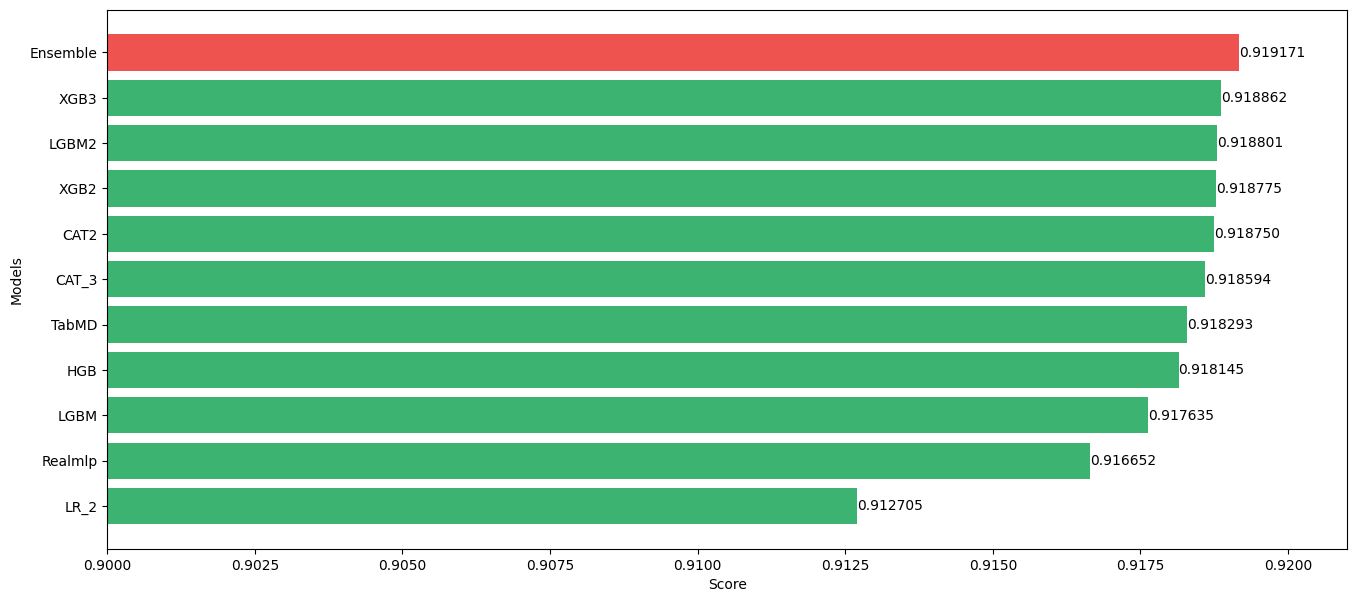

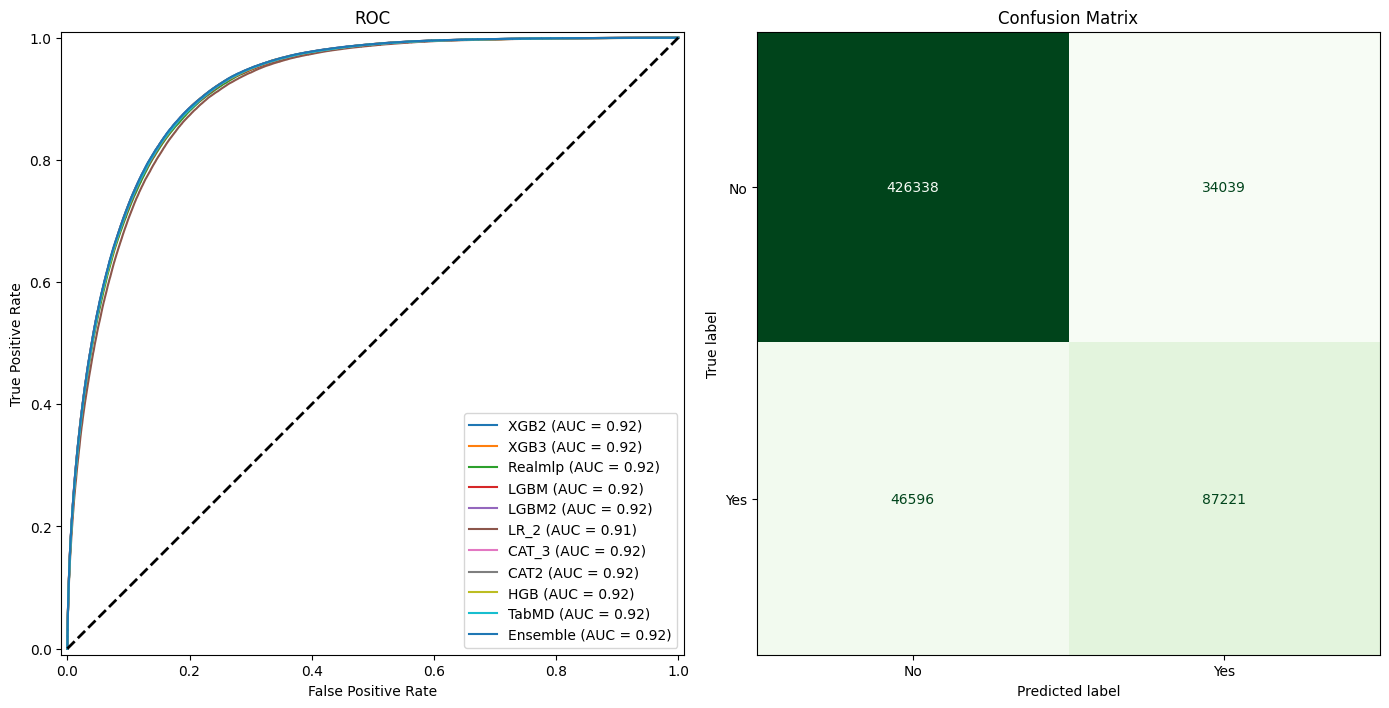

In [12]:
trainer = Trainer(X, y, test, models, num_features, cat_features, training=False)
TEST_preds, OOF_preds = trainer.run()

# <p style="border-radius: 40px; color: white; font-weight: bold; font-size: 150%; text-align: center; background-color:#3cb371; padding: 5px 5px 5px 5px;">Submission</p>

,id,Churn
0,594194,0.108915
1,594195,0.000581
2,594196,0.110017
3,594197,0.003382
4,594198,0.540120


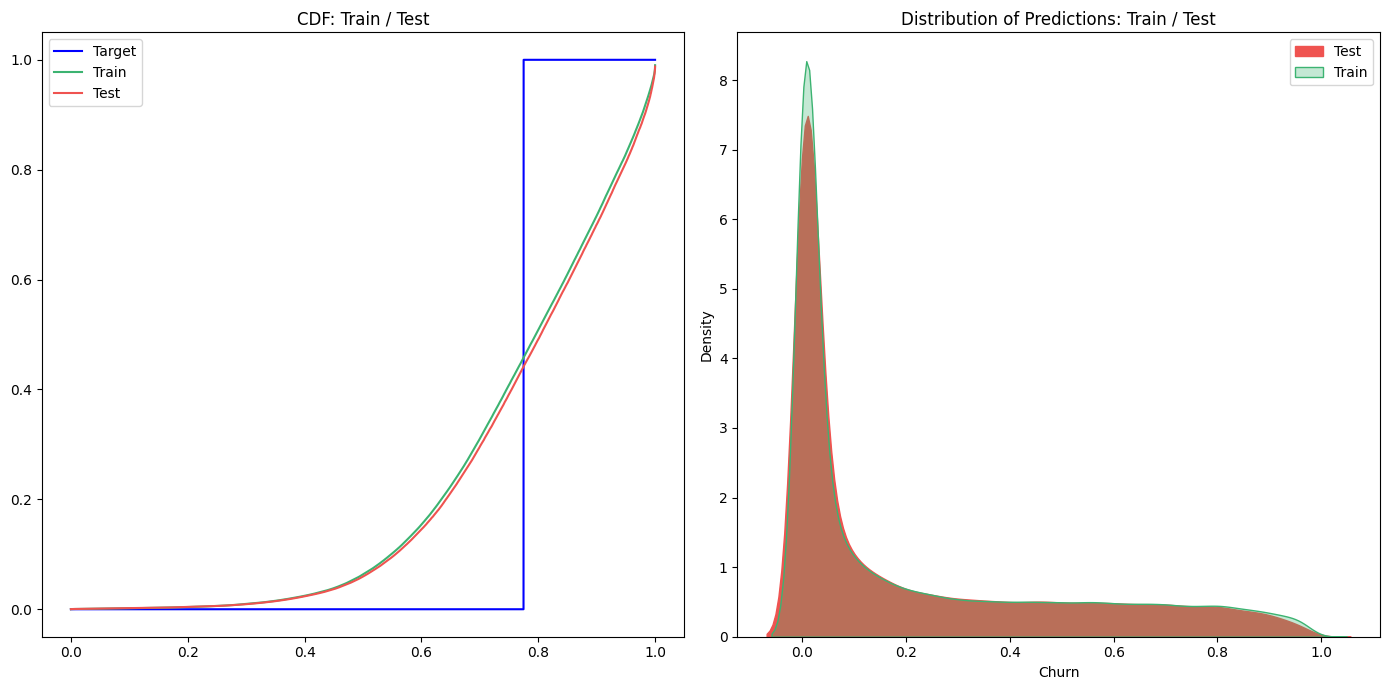

In [13]:
submission = Config.submission
submission[Config.target] = TEST_preds
submission.to_csv("submission.csv", index=False)
display(submission.head())

def plot_cdf(values, label, color, ax):
    sorted_vals = np.sort(values)
    y = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax.plot(y, sorted_vals, label=label, color=color)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# CDF
plot_cdf(y, "Target", color='blue', ax=axes[0])
plot_cdf(OOF_preds, "Train", color='#3cb371', ax=axes[0])
plot_cdf(submission[Config.target], "Test", color='#ef5350', ax=axes[0])
axes[0].legend()
axes[0].set_title("CDF: Train / Test")

# KDE
sns.kdeplot(submission[Config.target], label='Test', fill=True, color='#ef5350', alpha=1., ax=axes[1])
sns.kdeplot(OOF_preds, label='Train', fill=True, color='#3cb371', alpha=0.3, ax=axes[1])
axes[1].set_title('Distribution of Predictions: Train / Test')
axes[1].legend()

plt.tight_layout()
plt.show()